In [1]:
import pandas as pd
import numpy as np

# 1. Load the clean interim data
df = pd.read_csv("../data/interim/wmt_pl_annual.csv")

# 2. Calculate Efficiency Ratios (Margins)
# Margin = (Profit Metric / Revenue) * 100
df['GrossMargin_%'] = (df['GrossProfit'] / df['Revenue']) * 100
df['OpMargin_%'] = (df['OperatingIncome'] / df['Revenue']) * 100
df['NetMargin_%'] = (df['NetIncome'] / df['Revenue']) * 100

# 3. Calculate Year-over-Year (YoY) Growth Rates
# We use pct_change() which calculates the percentage change between the current and a prior element.
df['Revenue_YoY_%'] = df['Revenue'].pct_change() * 100
df['EBIT_YoY_%'] = df['OperatingIncome'].pct_change() * 100

# Fill the NaN values in the first year (since there's no prior year to compare to)
df = df.fillna(0)

# Round everything nicely for executive viewing (2 decimal places)
df = df.round(2)

# 4. Save this enriched data to our processed folder
processed_path = "../data/processed/wmt_pl_enriched.csv"
df.to_csv(processed_path, index=False)

print("✅ FP&A Feature Engineering Complete. Data saved to processed folder.")
print("\n📊 Executive Financial Summary:")
# Displaying the most recent 5 years of the new KPIs
display_cols = ['FiscalYear', 'Revenue', 'Revenue_YoY_%', 'GrossMargin_%', 'OpMargin_%', 'NetMargin_%']
print(df[display_cols].tail(5).to_string(index=False))

✅ FP&A Feature Engineering Complete. Data saved to processed folder.

📊 Executive Financial Summary:
 FiscalYear  Revenue  Revenue_YoY_%  GrossMargin_%  OpMargin_%  NetMargin_%
       2022   523.96           0.00          19.78        4.30         2.58
       2023   611.29          16.67          31.24        3.34         2.21
       2024   648.12           6.03          24.38        4.17         2.39
       2025   680.98           5.07          24.85        4.31         2.85
       2026   713.16           4.73          24.93        4.18         3.07


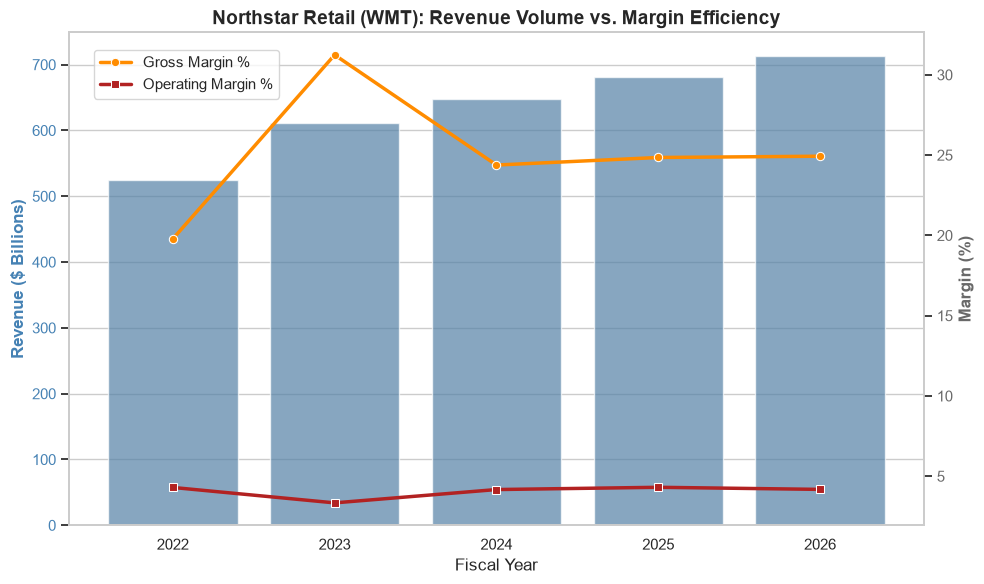

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the last 5 years for a clean chart
plot_df = df.tail(5).copy()
# Reset index so seaborn can plot the x-axis lines properly
plot_df.reset_index(drop=True, inplace=True)

# 1. Set up the figure and style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

# 2. Plot Revenue as a Bar Chart (Left Y-Axis)
sns.barplot(
    x='FiscalYear', 
    y='Revenue', 
    data=plot_df, 
    color='steelblue', 
    alpha=0.7, 
    ax=ax1
)
ax1.set_ylabel('Revenue ($ Billions)', color='steelblue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Fiscal Year', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# 3. Plot Margins as Line Charts (Right Y-Axis)
ax2 = ax1.twinx()
# We use the DataFrame index (0 to 4) for the x-coordinates of the line plot to align with the categorical bars
sns.lineplot(
    x=plot_df.index, 
    y='GrossMargin_%', 
    data=plot_df, 
    color='darkorange', 
    marker='o', 
    linewidth=2.5, 
    ax=ax2, 
    label='Gross Margin %'
)
sns.lineplot(
    x=plot_df.index, 
    y='OpMargin_%', 
    data=plot_df, 
    color='firebrick', 
    marker='s', 
    linewidth=2.5, 
    ax=ax2, 
    label='Operating Margin %'
)

ax2.set_ylabel('Margin (%)', color='dimgrey', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='dimgrey')
ax2.grid(False) # Turn off right-axis grid to avoid messy crossing lines

# 4. Final touches
plt.title('Northstar Retail (WMT): Revenue Volume vs. Margin Efficiency', fontsize=14, fontweight='bold')
fig.tight_layout()

# Move legend outside the plot
ax2.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98))

plt.show()